# Objectif du notebook 

Date de création : 25/06/2026

Reprise des résultats JASA-EL pour analyse par manifold learning 
 

In [2]:
import os 
import sys 
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt  

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from real_data_analysis.fiberscope_20.src import params
from real_data_analysis.fiberscope_20.src.utils import optimum_stft_params, apply_rtf_mfp
from real_data_analysis.fiberscope_20.src.fiberscope_manager import FiberscopeManager
from real_data_analysis.fiberscope_20.src.fiberscope_recording import (
    FiberscopeSweep1,
)
from propa.rtf.rtf_utils import normalize_metric_contrast, D_hermitian_angle_fast

from publication.publication_figure import color, PubFigure, set_subfigures_abc_labels

pfig = PubFigure()

### Commentaires 

Cette représentation permet d'observer la bonne correspondance des vecteurs de RTFs. 

In [3]:

root_dyn_files = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\localisation\rtf_mfp\cs-evd\dynamic_1pulses"
dyn_files = os.listdir(root_dyn_files)
rtf_dyn_files = [f for f in dyn_files if "rtf" in f]

# Sort files by distance
rdist = [float(f.split("_r")[1].split("m")[0]) for f in rtf_dyn_files]
idx_rdist_sort = np.argsort(rdist)
rtf_dyn_files = [rtf_dyn_files[i] for i in idx_rdist_sort]


# fpath_dyn = os.path.join(root_dyn_files, rtf_dyn_files[idx_snapshot])
# rtf_dyn = xr.open_dataset(fpath_dyn)

# Build module matrix 
mod_mat = []
phi_mat = []
for file in rtf_dyn_files:
    fpath_dyn = os.path.join(root_dyn_files, file)
    rtf_dyn_i = xr.open_dataset(fpath_dyn)

    mod_mat.append(rtf_dyn_i.rtf_amp_hat.values)
    phi_mat.append(rtf_dyn_i.rtf_phase_hat.values)

mod_mat = np.array(mod_mat)
phi_mat = np.array(phi_mat)


In [4]:
mod_mat.shape # -> (npos, nrcv, nf)

(274, 5, 2458)

In [5]:
rtf_dyn = rtf_dyn_i
rtf_dyn_all = xr.Dataset(
    data_vars=dict(
        rtf_amp=(["replica_id", "h_index", "f_rtf"], mod_mat),
        rtf_phase=(["replica_id", "h_index", "f_rtf"], phi_mat),
    ),
    coords=dict(
        replica_id=np.arange(mod_mat.shape[0]), 
        h_index = rtf_dyn.h_index.values,
        f_rtf = rtf_dyn.f_rtf.values,
    )
)

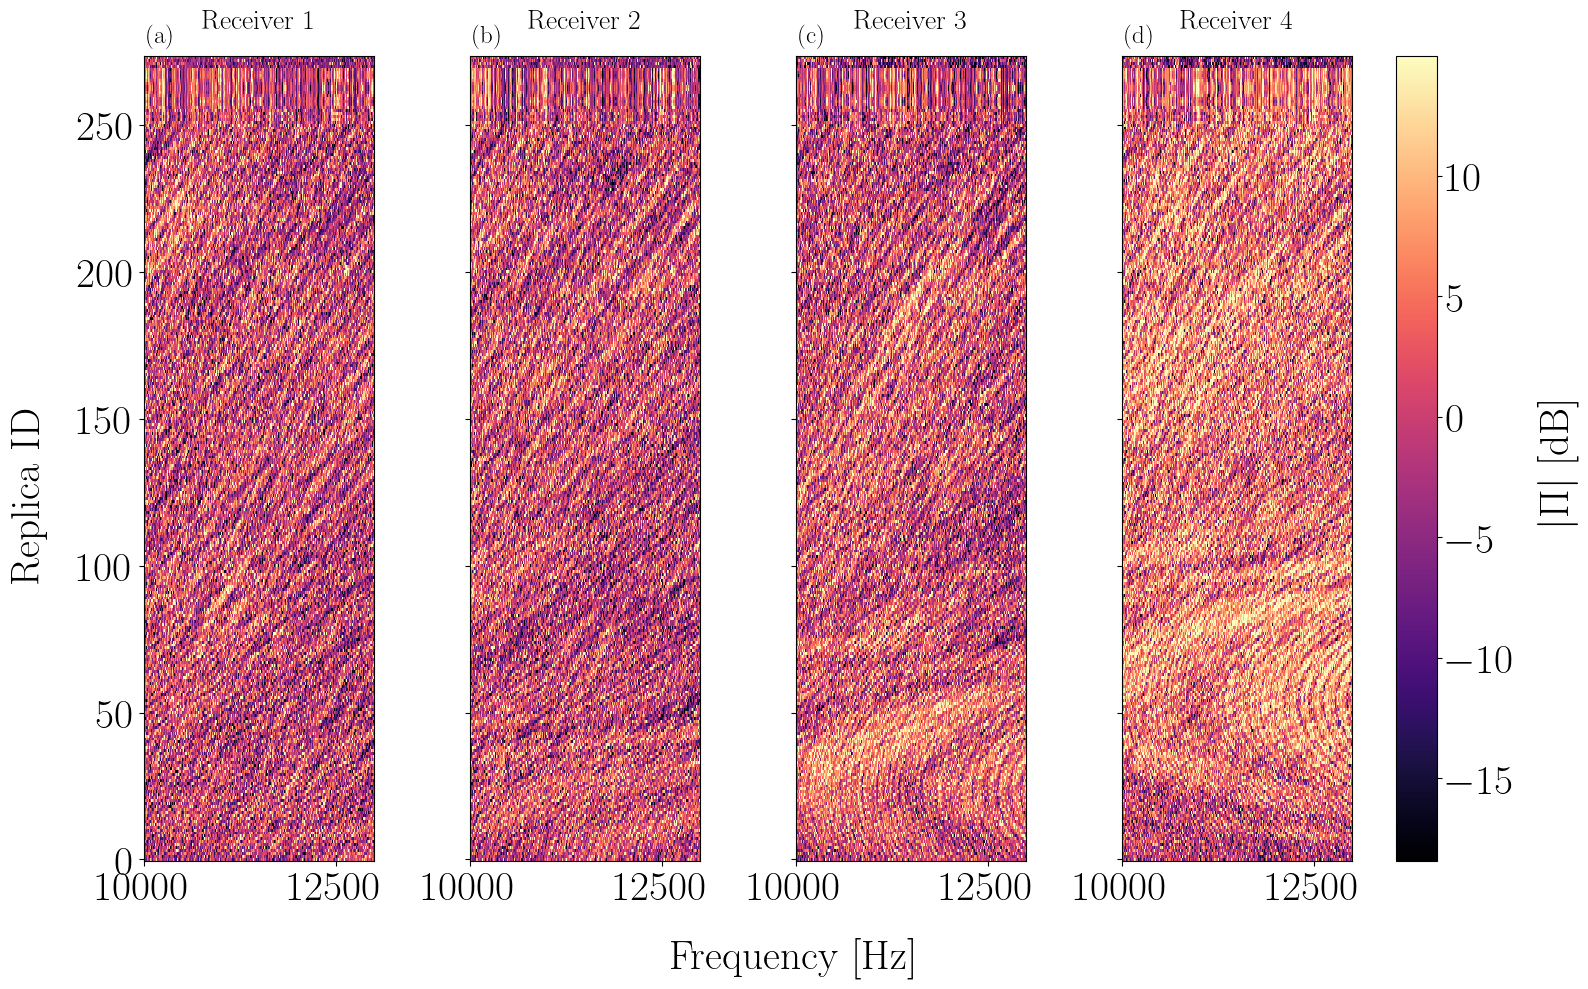

In [8]:
fmin = 10000
fmax = 13000

# Compare module for each rcv
idx_rcv_plot = [
    idx for idx in rtf_dyn.h_index.values if idx != rtf_dyn.h_index_ref
]

fig, axs = plt.subplots(nrows=1, ncols=len(idx_rcv_plot), sharex=True, sharey=True, figsize=(16, 10))

vmin=np.percentile(20 * np.log10(rtf_dyn_all.rtf_amp.sel(h_index=idx_rcv_plot).sel(f_rtf=slice(fmin, fmax))), 1)
vmax=np.percentile(20 * np.log10(rtf_dyn_all.rtf_amp.sel(h_index=idx_rcv_plot).sel(f_rtf=slice(fmin, fmax))), 95)

for i_ax, id_rcv in enumerate(idx_rcv_plot):
    ax_mod = axs[i_ax]
    # Module
    log_mod = 20 * np.log10(
        rtf_dyn_all.rtf_amp.sel(h_index=id_rcv).sel(f_rtf=slice(fmin, fmax))
    )
    im = log_mod.plot(
        x="f_rtf",
        ax=ax_mod,
        cmap="magma",
        # cbar_kwargs={"label": r"$\lvert \Pi \rvert$"},
        add_colorbar=False,
        vmin=vmin,
        vmax=vmax,
        # color=color(1), label=r"$|\Pi|^{(dyn)}$"
    )
    # ax_mod.set_ylim([0.01, 100])
    # ax_mod.set_yscale("log")
    ax_mod.set_xlabel("")
    ax_mod.set_ylabel("")
    ax_mod.set_title(f"Receiver {id_rcv}", fontsize=20)
    # ax_mod.legend()

    # # Add annotation for receiver index and record name
    # ax_mod.annotate(
    #     f"Rcv: {h_plot}",
    #     xy=(0.96, 0.9),
    #     xycoords="axes fraction",
    #     fontsize=10,
    #     color="black",
    #     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
    # )

clabel =  r"$\lvert \Pi \rvert$ [dB]"
fig.colorbar(
    im,
    ax=axs.ravel().tolist(),
    label=clabel,
    orientation="vertical",
    fraction=1.0,
    pad=0.03,
)

fig.supxlabel("Frequency [Hz]")
fig.supylabel("Replica ID")

set_subfigures_abc_labels(
    axs=axs,
    fontsize=18,
    x_pos=0.015,
    y_pos=1.01,
    ha="left",
    va="bottom",
)

# fpath = os.path.join(
#     r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localisation\rtf_mfp", 
#     "pi_f_r_plan.png"
# )
# plt.savefig(fpath, dpi=300)

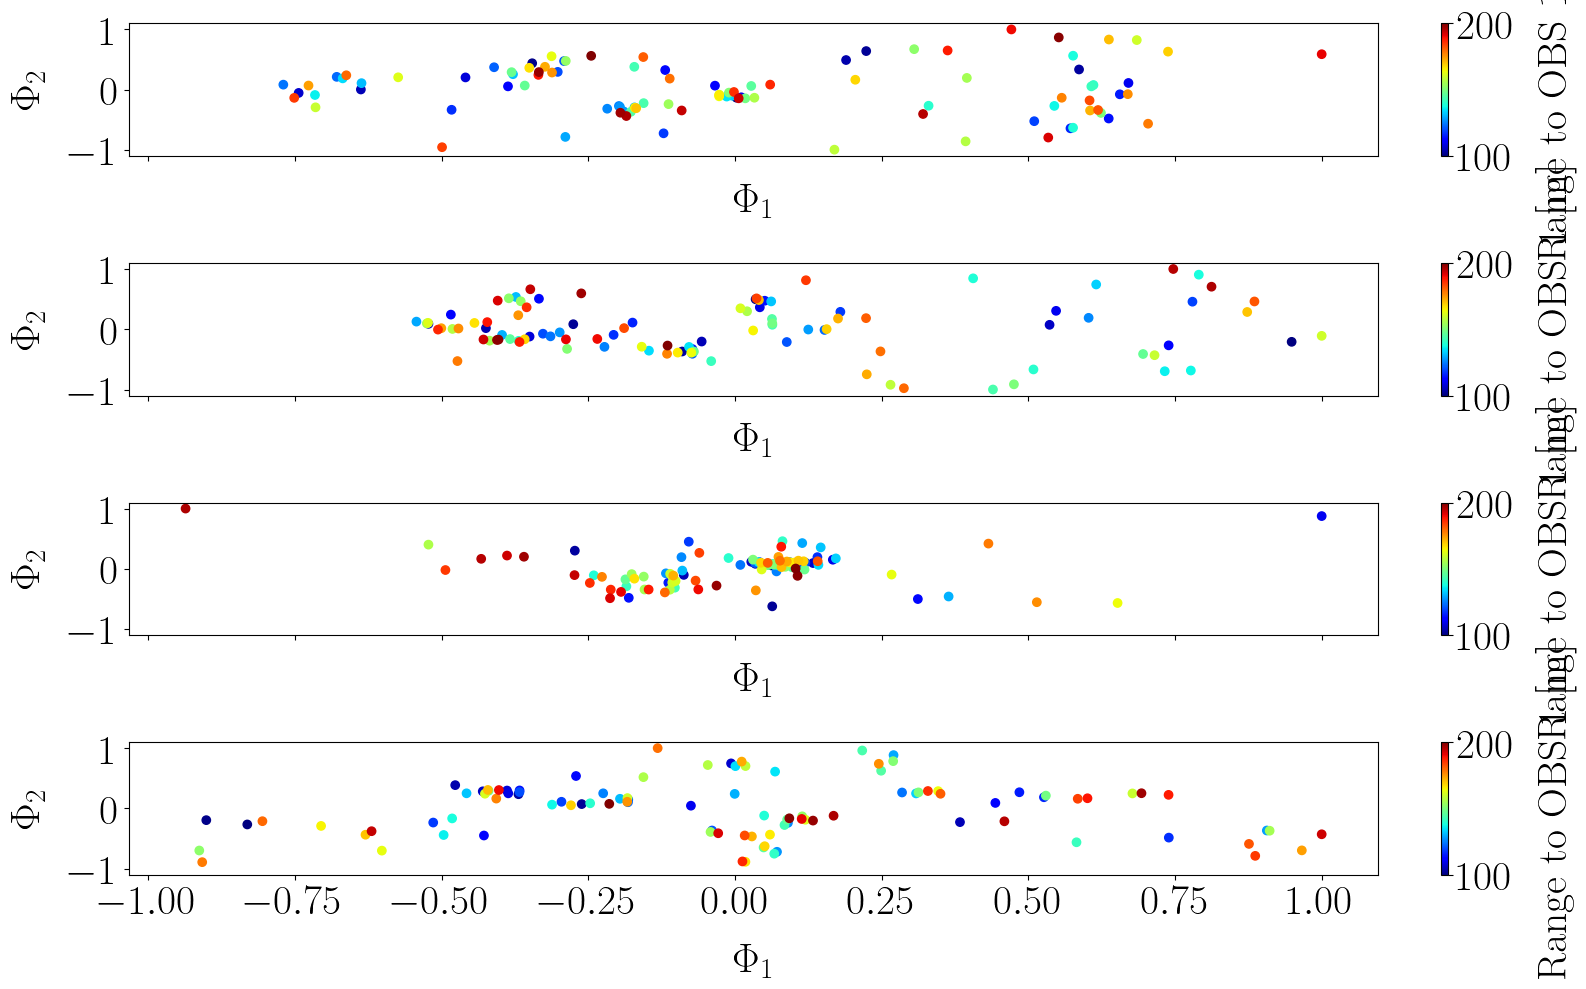

In [35]:
from sklearn import manifold

# p  = 2 -> distance euclidienne
p = 1
n_neighbors = 3
n_components = 2  # Dimensionnality of the embeding space
rtf_dyn_all_sel = rtf_dyn_all.sel(replica_id=slice(100, 200))

fig, axs = plt.subplots(
    nrows=len(idx_rcv_plot), ncols=1, sharex=True, sharey=True, figsize=(16, 10)
)

for i_ax, id_rcv in enumerate(idx_rcv_plot):
    ax_mod = axs[i_ax]
    # Module
    # log_mod = 20 * np.log10(
    #     rtf_dyn_all.rtf_amp.sel(h_index=id_rcv).sel(f_rtf=slice(fmin, fmax))
    # )

    data = (
        rtf_dyn_all_sel.rtf_amp.sel(h_index=id_rcv).sel(f_rtf=slice(fmin, fmax)).values
    )  # Input must be (n_sample, n_features)
    # Normalize data
    # data = data / np.max(data)

    isomap_simu = manifold.Isomap(n_neighbors=n_neighbors, n_components=n_components, p=p)
    data_transformed_simu = isomap_simu.fit_transform(data)

    if n_components == 2:
        sc = axs[i_ax].scatter(
            data_transformed_simu[:, 0] / np.max(data_transformed_simu[:, 0]),
            data_transformed_simu[:, 1] / np.max(data_transformed_simu[:, 1]),
            c=rtf_dyn_all_sel.replica_id.values,
            cmap="jet",
        )
        plt.colorbar(sc, ax=axs[i_ax], label="Range to OBS 1 [m]")
        axs[i_ax].set_xlabel(r"$\Phi_1$")
        axs[i_ax].set_ylabel(r"$\Phi_2$")

    elif n_components == 1:

        sc = axs[i_ax].scatter(
            rtf_dyn_all_sel.replica_id.values,
            data_transformed_simu[:, 0] / np.max(data_transformed_simu[:, 0]),
            # data_transformed_simu[:, 1],
            # c=tf_obs1_range_sel.r.values,
            # cmap="jet",
        )
        # plt.colorbar(sc, label="Range to OBS 1 [m]")
        axs[i_ax].set_ylabel(r"$\Phi_1$")

# plt.xlim([-0.15, 0])